## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [2]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB
from torch.utils.data import random_split

# Your code here.
device= 'cuda' if torch.cuda.is_available() else "cpu"

print(f"Versione PyTorch: {torch.__version__}")
print(f"Versione CUDA interna: {torch.version.cuda}")
print(f"Device:{device}")

Versione PyTorch: 2.8.0
Versione CUDA interna: None
Device:cpu


In [9]:
def init_datasets(trasform_application=None):
    ds_test= GTSRB('_data/',split='test',transform=trasform_application ,download=True)
    ds_full_train= GTSRB('_data/',split='train', transform=trasform_application, download=True)
    
    #I will take the 25% of training set for the validation set
    train_size = int(len(ds_full_train)*0.75)
    val_size = len(ds_full_train) - train_size
    
    generator = torch.Generator().manual_seed(42)
    ds_train, ds_val = random_split(ds_full_train, [train_size, val_size], generator=generator)
    
    
    print(f"Train Full:\n{ len(ds_full_train)}")
    print(f"Total Images: {len(ds_full_train) + len(ds_test)}")
    print(f"Validation Set:\n {len(ds_val)}")
    print(f"Train Set:\n {len(ds_train)}")
    print(f"Test:\n {len(ds_test)}")
    return ds_train, ds_val, ds_test

As first consideration, we have downloaded the data GTSRB and there are two partition looking in the PyTorch documentation. The first one is the Test Dataset and has 12630 samples, meanwhile the train one has the double of samples.
Now, we can try to analyze how is composed the dataset.

In [10]:
#Looking for the shape of this structure.
transform1 = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

ds_train, ds_val, ds_test = init_datasets(trasform_application=transform1)

print(f"Dimension: {ds_train[0][0].shape}")

ds_train[0][0]

Train Full:
26640
Totale immagini: 39270
Validation Set:
 6660
Train Set:
 19980
Test:
 12630
Dimension: torch.Size([3, 34, 32])


Image([[[0.8314, 0.8392, 0.8275,  ..., 0.5647, 0.4706, 0.4000],
        [0.8431, 0.8275, 0.8314,  ..., 0.3765, 0.3294, 0.3255],
        [0.8196, 0.8157, 0.8196,  ..., 0.4706, 0.4078, 0.3725],
        ...,
        [0.7333, 0.7333, 0.7373,  ..., 0.6510, 0.6196, 0.5843],
        [0.7216, 0.7255, 0.7333,  ..., 0.6431, 0.6275, 0.6392],
        [0.7294, 0.7216, 0.7294,  ..., 0.6941, 0.6941, 0.6549]],

       [[0.8431, 0.8549, 0.8510,  ..., 0.5725, 0.5020, 0.4353],
        [0.8549, 0.8431, 0.8510,  ..., 0.3765, 0.3529, 0.3529],
        [0.8353, 0.8314, 0.8392,  ..., 0.4667, 0.4275, 0.3922],
        ...,
        [0.7451, 0.7412, 0.7373,  ..., 0.6588, 0.6275, 0.5843],
        [0.7333, 0.7255, 0.7255,  ..., 0.6510, 0.6431, 0.6392],
        [0.7451, 0.7294, 0.7333,  ..., 0.7059, 0.7020, 0.6588]],

       [[0.8745, 0.8863, 0.8667,  ..., 0.5765, 0.5020, 0.4314],
        [0.8902, 0.8824, 0.8706,  ..., 0.3686, 0.3373, 0.3255],
        [0.8667, 0.8627, 0.8549,  ..., 0.4667, 0.4235, 0.3804],
        ..

The tensor has shape (C, H, W) where C=3 represents the RGB channels.
Each channel contains a 2D matrix of size H × W, representing the pixel intensities of that color component.
Therefore, the image is stored as three separate matrices corresponding to the Red, Green, and Blue channels.

At this point, we can see all the image for all classes.

In [11]:
def visualize_all_classes(ds,num_cols):
    #max_label = max(label for _, label in ds_train)
    max_label=43
    print(f"Max Class: {max_label}")
    image_per_label = {}

    for img, label in ds:
        if label not in image_per_label:
            image_per_label[label] = img
        if len(image_per_label) == max_label:
            break
    rows= (max_label //num_cols) + 1 
    plt.figure(figsize=(15,10))

    for i, (label,img) in enumerate(sorted(image_per_label.items())):
        plt.subplot(rows, num_cols, i+1)

        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()
            
        if img.min() < 0:
            img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()    

Max Class: 43


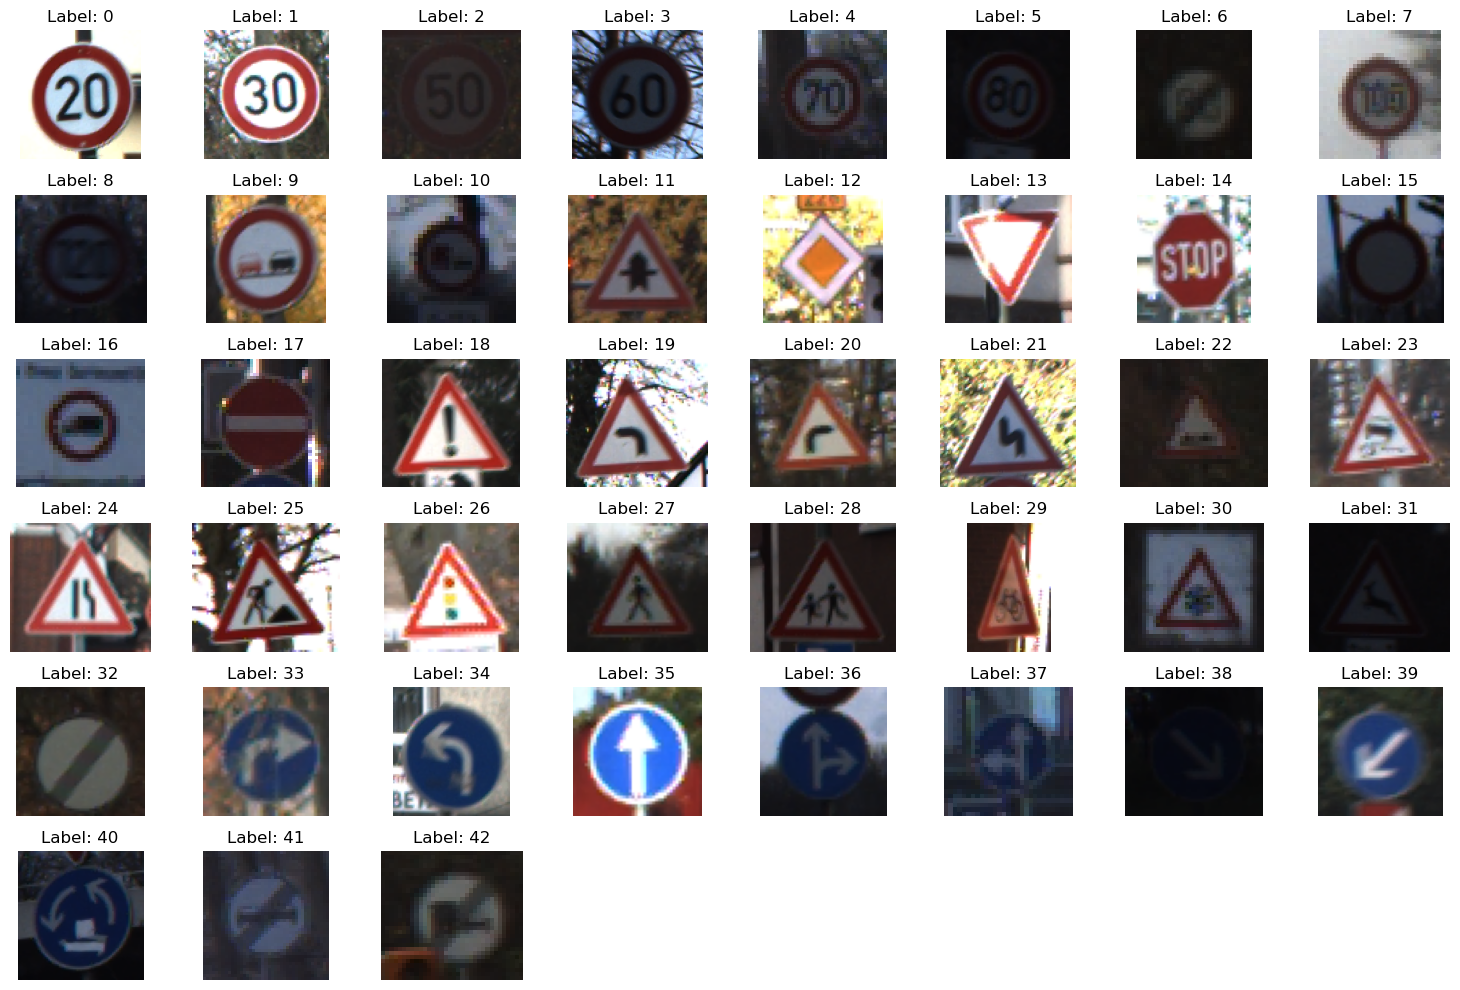

In [12]:
visualize_all_classes(ds_train,8)

With this function, we can see thathe dataset has 42 categories of traffic signs.\
What we can analyse is if the dataset is bilanced or all the image have the same dimension. 

In [13]:
import pandas as pd
# We can create dataframe 

df_stats = pd.DataFrame([(cls, img.shape[1],img.shape[2]) for (img,cls) in ds_train], columns=["Class","Height", "Width"])

In [6]:
df_stats["Aspect Rateo"]=df_stats["Width"] / df_stats["Height"]  
df_stats.describe()

,Class,Height,Width,Aspect Rateo
count,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,1.008718
std,12.044099,23.161523,24.373418,0.072100
min,0.000000,25.000000,25.000000,0.368132
25%,5.000000,35.000000,35.000000,0.972222
50%,12.000000,43.000000,43.000000,1.000000
75%,25.000000,58.000000,58.000000,1.044444
max,42.000000,225.000000,243.000000,1.417808


array([[<Axes: title={'center': 'Class'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Aspect Rateo'}>]], dtype=object)

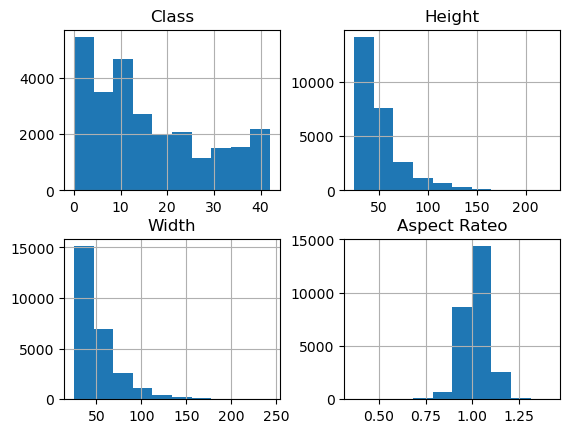

In [7]:
df_stats.to_csv("dataframe.csv",index=False)
df_stats.hist()

In these graphs, we can observe that:

- The images do not all have the same size, so we need to apply cropping to make them uniform in dimensions.

- A large portion of the dataset consists of images with dimensions of 50×50 pixels.

- The classes are not perfectly balanced; we could apply some techniques to address this issue.

/home/deste00/miniconda3/envs/FML/lib/python3.13/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Max Class: 43


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15266106..2.4285715].


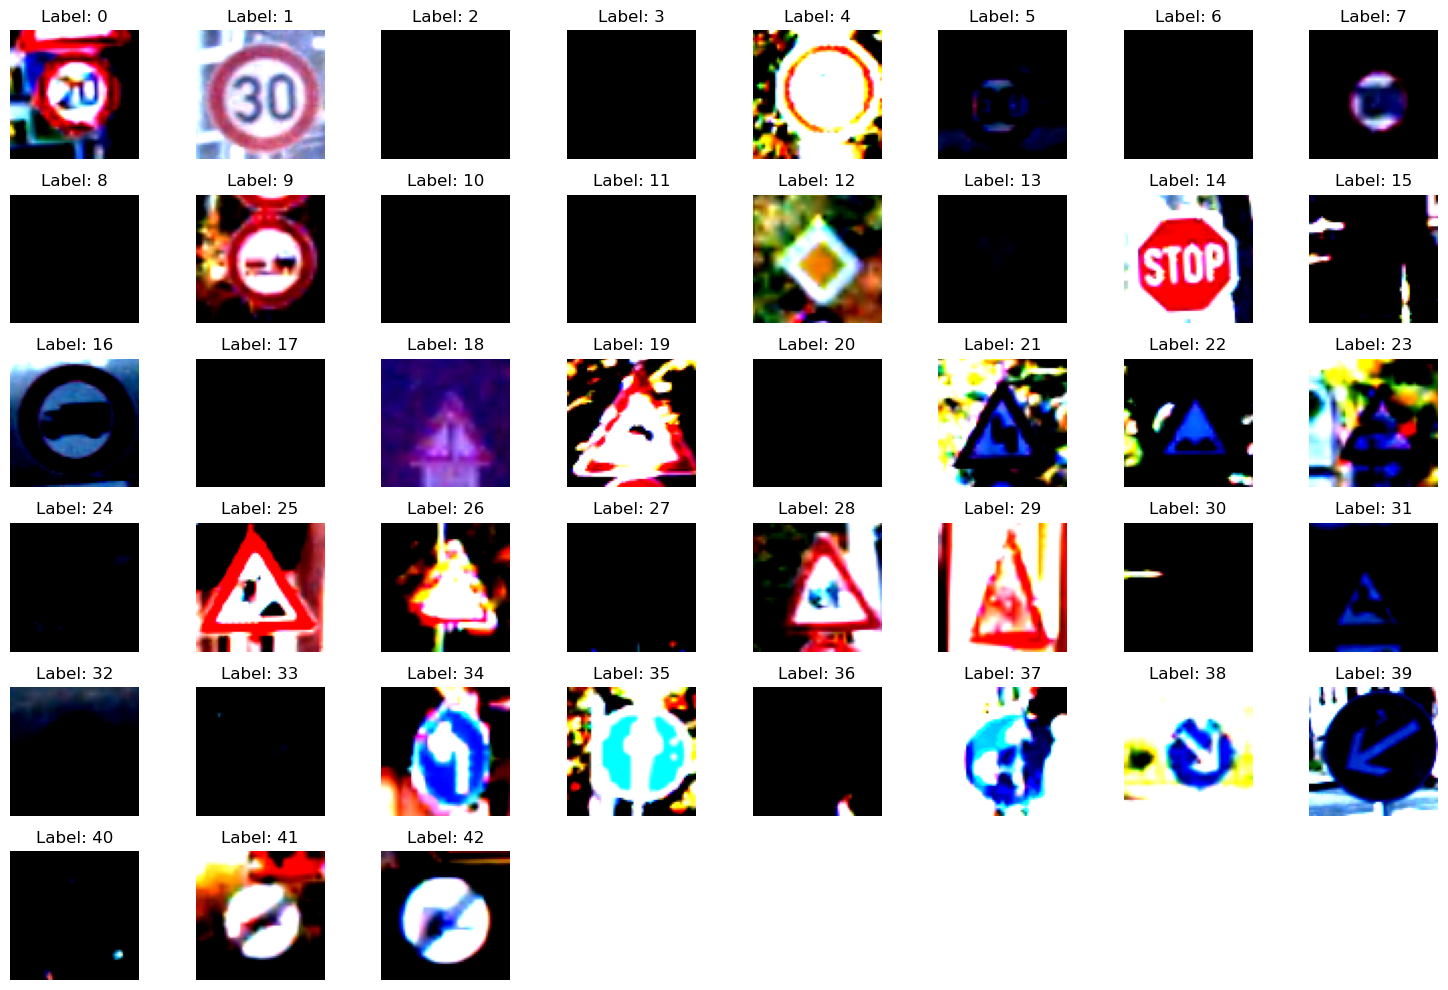

In [8]:
#See in the resnet or CNN used.
final_transform = T.Compose([T.Resize(70),T.RandomCrop((64,64)),T.ToTensor(), T.Normalize(mean=[0.485,0.456, 0.406], std=[0.229,0.224,0.225])])
#In this case, we applies the trasformation on the dataset
ds_train, ds_val, ds_test = init_datasets(final_transform)
#Visualize the trasformation.
visualize_all_classes(ds_train,8)

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [9]:
from torchvision.models import list_models, get_model

list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [22]:
from torch.utils.data import DataLoader

#Create a DataLoader
def init_dataloaders(ds_train, ds_val, ds_test, batchsize=1024)
    
    dl_train = DataLoader(ds_train, batch_size=batchsize, shuffle=True)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle = False)
    dl_test = DataLoader(ds_test, batch_size= batchsize, shuffle=False)
    return dl_train, dl_val, dl_test

#The weights are of a training on 1K Dataset ImageNet
model= get_model("resnet18", weights='DEFAULT').to(device)

In [23]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [43]:
import torch.nn as nn

model.fc= nn.Identity()
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def visualize_output_embedding(embedding):
    if isinstance(embedding, torch.Tensor):
        emb_array = embedding_tensor.detach().cpu().numpy().squeeze()
    else:
        emb_array = np.squeeze(embedding) # Nel caso fosse già un array numpy
        
    # Controllo di sicurezza
    assert emb_array.shape[0] == 512, f"Attenzione: l'embedding ha dimensione {emb_array.shape}, ci servono esattamente 512 elementi!"
    
    # 2. La magia: trasformiamo la linea di 512 numeri in un'immagine 16x32
    emb_image = emb_array.reshape(16, 32)
    
    # 3. Disegniamo l'immagine
    plt.figure(figsize=(10, 4))
    
    # Puoi cambiare 'cmap' con 'hot', 'magma' o 'cividis' se preferisci altri colori
    plt.imshow(emb_image, cmap='viridis', aspect='auto', interpolation='nearest') 
    
    plt.colorbar(label='Livello di Attivazione (Valore numerico)')
    plt.title("Visualizzazione dell'Embedding 512D (Griglia 16x32)", fontsize=14)
    plt.axis('off') # Nascondiamo gli assi X e Y perché non sono coordinate spaziali
    plt.tight_layout()
    plt.show()
    
    
    

In [31]:
from tqdm.notebook import tqdm
def create_dataset_features(dataloader):
    outputs_features = []
    classes_features = []
    
    for imgs, cls in tqdm(dataloader):
        imgs = imgs.to(device)
        
        with torch.no_grad():
            # Fondamentale: spostiamo le feature calcolate sulla CPU prima di metterle nella lista!
            features = model(imgs).cpu()
            outputs_features.append(features)
            
        classes_features.append(cls)
    
    outputs_features = torch.vstack(outputs_features)
    classes_features = torch.cat(classes_features)
    return outputs_features, classes_features

In [32]:
print("Features Extractor for all images of the train dataset")
train_feat, train_class_feat = create_dataset_features(dl_train)
print("Features Extractor for all images of the test dataset")
test_feat, test_class_feat = create_dataset_features(dl_test)

Features Extractor for all images of the train dataset


  0%|          | 0/27 [00:00<?, ?it/s]

Features Extractor for all images of the test dataset


  0%|          | 0/13 [00:00<?, ?it/s]

In [33]:
from sklearn.svm import SVC

svc =  SVC(kernel='linear')
svc.fit(train_feat, train_class_feat)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [70]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(svc.predict(test_feat), test_class_feat))

              precision    recall  f1-score   support

           0       0.25      0.22      0.23        69
           1       0.53      0.39      0.45       978
           2       0.42      0.37      0.39       856
           3       0.32      0.26      0.29       564
           4       0.41      0.43      0.42       626
           5       0.28      0.36      0.31       487
           6       0.77      0.78      0.78       149
           7       0.46      0.48      0.47       424
           8       0.28      0.33      0.30       381
           9       0.51      0.61      0.56       403
          10       0.70      0.70      0.70       662
          11       0.51      0.37      0.43       580
          12       0.87      0.80      0.83       749
          13       0.89      0.83      0.86       776
          14       0.68      0.86      0.76       215
          15       0.87      0.86      0.86       214
          16       0.74      0.76      0.75       146
          17       0.63    


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [7]:
import torch
import torch.optim as optim



def train_epoch(model, dl, opt, epoch='Unknown', device='cpu'):
    model.train()
    cross_entropy = nn.CrossEntropyLoss()
    losses = []
    for (xs,ys) in dl:
        xs=xs.to(device)
        ys=ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = cross_entropy(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

def validation_epoch(model,dl,opt,epoch='Unknown', device='cpu'):
    model.eval()
    losses=[]
    cross_entropy = nn.CrossEntropyLoss()
    for (xs,ys) in dl:
        xs.to(device)
        ys.to(device)
        logits=model(xs)
        loss= cross_entropy(logits,ys)
        losses.append(loss.item())
    return np.mean(losses)    

def evaluate_model(model, dl, device='cpu',checkpoint=False):
    model.eval()
    predictions = []
    gts = []
    for (xs,ys) in tqdm(dl, desc='Evaluating', leave= False):
        xs= xs.to(device)
        preds = torch.argmax(model(xs), dim=1)
        gts.append(ys)
        predictions.append(preds.detach().cpu().numpy())

    return (accuracy_score(np.hstack(gts), np.hstack(predictions)),
            classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0,digits=3)
           )

def count_parameters(model):
    return np.sum([p.numel() for p in model.parameters()])

def plotting_val_test_acc_loss(losses_train, losses_val, accuracy_train, accuracy_score):
    plt.figure(figsize=(15,15))
    plt.subplot(1,)
    plt.show()
    

def finetuning_a_model(model, dl_train,dl_val, dl_test ,device='cpu', classificator= None, epochs=40, freezing=False, early_stop_max=5, lr_rate= 0.0001): 
    wandb.init(
        project="Traffic_Signs_Project", 
        name=f"ResNet18_Full_Finetuning_{model.model.__class__.__name__}", 
        config={
            "learning_rate": lr_rate,
            "epochs": epochs,
            "architecture": "ResNet18"
        }
    )
    
    #freeze all parameters of the RCNN backbone
    if freezing is True:
        for p in model.parameters():
            p.requires_grad_(False)
            
    if (classificator is None):
        model.fc = nn.Linear(512, 43)
    else:
        model.fc = classificator
        
    model.to(device)
    opt = optim.Adam(model.fc.parameters(), lr=0.001)
    best_model= model

    min_loss= np.inf
    losses_train = []
    losses_val = []

    early_stop_counter = 0
    for epoch in tqdm(range(epochs)):
        
        loss_train = train_epoch(model, dl_train, opt, epoch=epoch, device=device)
        loss_val = validation_epoch(model, dl_val, opt, epoch=epoch, device=device)
        loss_val.append(loss_val)
        loss_train.append(loss_train)

        acc, report_dict, _ = evaluate_model(model, dl_test, device=device)
        
        # Estraiamo le altre metriche dal dizionario di scikit-learn
        val_f1 = report_dict['macro avg']['f1-score']
        val_precision = report_dict['macro avg']['precision']
        
        wandb.log({
            "Train/Loss": loss_train,
            "Train/Accuracy": acc_val,
            "Validation/Loss": loss_val,
            "Validation/Accuracy": acc_val,
            "Validation/F1_Score": val_f1,
            "Validation/Precision": val_precision,
            "epoch": epoch
        })
        
        if (loss_val < min_loss):
            print("---- Loading new best Model ------\n")
            best_model.load_state_dict(model.state_dict())
            min_loss= loss_val
        elif early_stop_counter == early_stop_max:
            break           

    (accuracy, cls_report)= evaluate_model(model, dl_test, device=device)
    print(cls_report)
    wandb.finish()
    return accuracy, losses

In [84]:
#lr_rate=0.0001 is lower in the fine tuning of all model weight
linear_accuracy, linear_losses= finetuning_a_model(model,dl_train, dl_val, dl_test, device)

#lr_rate bigger in the fine tuning classificator
linear_f_accuracy,linear_f_losses= finetuning_a_model(model, dl_train, dl_test, device, freezing=True,lr_rate=0.001)

#Trying with a MultiLayer Perceptron
classificator_MLP = nn.Sequential(nn.Linear(512,256),nn.ReLU(),nn.Linear(256, 43))
finetuning_a_model(model,dl_train, dl_val, dl_test, device, classificator = classificator_MLP)


#No need to use Softmax, if there's Cross_Entropy in the field

from sklearn.neighbors import KNeighborsClassifier
model_KNN = KNeighborsClassifier(n_neighbors=k)


  0%|          | 0/40 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0      0.095     0.067     0.078        60
           1      0.510     0.497     0.504       720
           2      0.416     0.449     0.432       750
           3      0.282     0.216     0.244       450
           4      0.434     0.470     0.451       660
           5      0.304     0.432     0.357       630
           6      0.692     0.793     0.739       150
           7      0.519     0.547     0.532       450
           8      0.322     0.273     0.296       450
           9      0.688     0.473     0.560       480
          10      0.666     0.764     0.711       660
          11      0.449     0.405     0.426       420
          12      0.819     0.900     0.858       690
          13      0.823     0.924     0.870       720
          14      0.856     0.637     0.730       270
          15      0.915     0.876     0.895       210
          16      0.874     0.740     0.801       150
          17      0.827    

  0%|          | 0/40 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0      0.191     0.150     0.168        60
           1      0.502     0.475     0.488       720
           2      0.409     0.480     0.441       750
           3      0.254     0.353     0.295       450
           4      0.404     0.436     0.420       660
           5      0.407     0.335     0.368       630
           6      0.775     0.780     0.777       150
           7      0.531     0.489     0.509       450
           8      0.290     0.304     0.297       450
           9      0.602     0.479     0.534       480
          10      0.669     0.747     0.706       660
          11      0.441     0.410     0.425       420
          12      0.838     0.864     0.851       690
          13      0.822     0.931     0.873       720
          14      0.844     0.659     0.740       270
          15      0.842     0.890     0.866       210
          16      0.812     0.780     0.796       150
          17      0.824    

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [17]:
# Your code here.

my_config = {
    "model" : "resnet18",
     "classificator" : nn.Linear(512,43),
    "learning_rate": 0.0001,
    "epochs": 40,
    "freezing": False,
    "transform" : T.Compose([T.Resize(70),T.RandomCrop((64,64)),T.ToTensor(), T.Normalize(mean=[0.485,0.456, 0.406], std=[0.229,0.224,0.225])]),
    "batch_size": 1024,
    "early_stop_max": 5
}


def pipeline_experiment(config):

    model = get_model(config["model"])
    
    device= 'cuda' if torch.cuda.is_available() else "cpu"
    
    ds_train, ds_val, ds_test = init_datasets(config["transform"])
    
    dl_train, dl_val, dl_test = init_dataloader(ds_train, ds_val, ds_test, config["batch_size"])

    finetuning_a_model(model, dl_train,dl_val, dl_test, device, config["classificator"], config["epochs"], config["freezing"], config["early_stop_max"], config["learning_rate"])

    return model

NameError: name 'nn' is not defined


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [16]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

In [17]:
# Your code here.


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [2]:
from datasets import load_dataset

ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

In [2]:
ds_train = ds['train']
ds_test =  ds['test']
ds_val = ds ['validation']

model_vision = get_model('fasterrcnn_resnet50_fpn', weights = 'DEFAULT')
weights = model_classificator.state_dict()
model_vision.backbone.load_state_dict(weights,strict=False)

import matplotlib.patches as patches

def draw_bounding_box(image ,boxes,labels, scores):
    fig,ax = plt.subplot(fig_size=(12,12))
    ax.imshow(image)

    for i,box in enumerate(boxes):
        # Takes the corner Top Right and Bottom Left
        x_min,x_max,y_min,y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle((x_min,y_min),width, height, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        if labels is not None:
            text = str(labels[i])
            if scores is not None:
                text += f"{scores[i]:.2f}"

            ax.text(
                x_min, y_min - 5, testo, 
                color='white', backgroundcolor='red', 
                fontsize=10, fontweight='bold'
            )

       plt.axis("off")
            
        

_IncompleteInputError: incomplete input (2214790308.py, line 25)

The seguent model is a vision model than it is trained with imageset very generic as background, persons, bycicles and other categories...\
So, we can train  our resnet, we will use a resnet 50 instead a 18 because the backbone is a resnet50, so the other parts of the CNN is adapted on that model.


Some things to do are:
1. Download the model resnet50.
2. Train that model with the previous dataset.
3. Modify the backbone of the Faster RCNN.
4. As output the model gave four coordinates of the bounding box.
5. With the function IoU we can have a loss and with that we can train the model.

---
---